In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign_data.csv to marketing_campaign_data (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('marketing_campaign_data.csv')
df.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,S1,Lajang,58138000.0,0,0,04-09-2012,58,...,7,0,0,0,0,0,0,3,11,1
1,1,2174,1954,S1,Lajang,46344000.0,1,1,08-03-2014,38,...,5,0,0,0,0,0,0,3,11,0
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,21-08-2013,26,...,4,0,0,0,0,0,0,3,11,0
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,10-02-2014,26,...,6,0,0,0,0,0,0,3,11,0
4,4,5324,1981,S3,Menikah,58293000.0,1,0,19-01-2014,94,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2240 non-null   int64  
 1   ID                   2240 non-null   int64  
 2   Year_Birth           2240 non-null   int64  
 3   Education            2240 non-null   object 
 4   Marital_Status       2240 non-null   object 
 5   Income               2216 non-null   float64
 6   Kidhome              2240 non-null   int64  
 7   Teenhome             2240 non-null   int64  
 8   Dt_Customer          2240 non-null   object 
 9   Recency              2240 non-null   int64  
 10  MntCoke              2240 non-null   int64  
 11  MntFruits            2240 non-null   int64  
 12  MntMeatProducts      2240 non-null   int64  
 13  MntFishProducts      2240 non-null   int64  
 14  MntSweetProducts     2240 non-null   int64  
 15  MntGoldProds         2240 non-null   i

In [ ]:
###Membuat Convertion Rate Berdasarkan Umur

In [ ]:
#membuat kolom umur berdasarkan tahun lahir
df['age'] = 2025 - df['Year_Birth']
df[['Year_Birth','age']].head()

,Year_Birth,age
0,1957,68
1,1954,71
2,1965,60
3,1984,41
4,1981,44


In [ ]:
#membuat kelompok umur
bins = [0,25,35,50,100]
labels = ['Young','Adult','Middle Age','Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df[['age','age_group']].head()

,age,age_group
0,68,Senior
1,71,Senior
2,60,Senior
3,41,Middle Age
4,44,Middle Age


In [ ]:
#Di dataset conversion = kolom Response. 1 = customer menerima campaign, 0 = tidak menerima
#menghitung conversion rate per umur
conversion_by_age = df.groupby('age_group')['Response'].mean().reset_index()
conversion_by_age

/tmp/ipykernel_302/2535695949.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_by_age = df.groupby('age_group')['Response'].mean().reset_index()


,age_group,Response
0,Young,NaN
1,Adult,0.229508
2,Middle Age,0.147838
3,Senior,0.146676


In [ ]:
df['age_group'].value_counts()

,count
age_group,
Senior,1459
Middle Age,717
Adult,61
Young,0


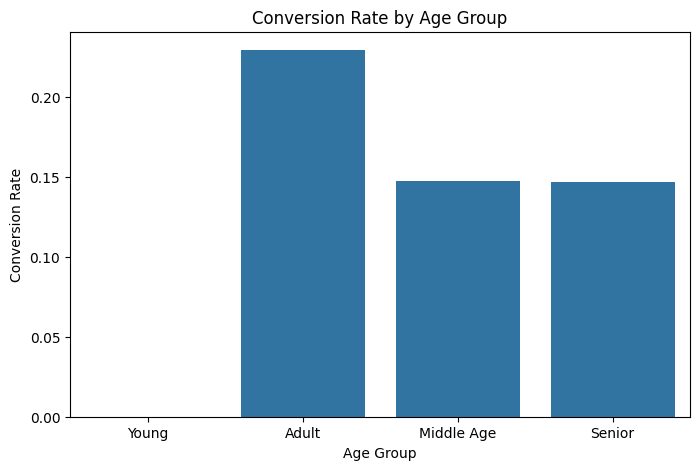

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='age_group', y='Response', data=conversion_by_age)

plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate')

plt.show()

In [ ]:
##Interpretasi Grafik
#Berdasarkan grafik Conversion Rate by Age Group, terlihat bahwa terdapat perbedaan tingkat conversion rate pada setiap kelompok umur pelanggan.
#Kelompok Adult memiliki conversion rate tertinggi dibandingkan kelompok umur lainnya, yang menunjukkan bahwa pelanggan pada kelompok umur ini memiliki kecenderungan lebih besar untuk merespon campaign marketing yang diberikan.

#Kelompok Middle Age memiliki conversion rate yang sedikit lebih rendah dibandingkan kelompok Adult, namun masih menunjukkan tingkat respon yang cukup baik terhadap campaign.
#Sementara itu, kelompok Senior memiliki conversion rate yang paling rendah di antara kelompok umur yang memiliki data respon.

#Selain itu, pada kelompok Young tidak terdapat nilai conversion rate yang muncul pada grafik.
#Hal ini mengindikasikan bahwa tidak terdapat pelanggan pada kelompok umur tersebut yang merespon campaign dalam dataset yang digunakan, sehingga conversion rate pada kelompok ini tidak dapat dihitung atau bernilai nol.

In [ ]:
###Membuat Convertion Rate Berdasarkan Income/Pendapatan

In [ ]:
df_income = df.dropna(subset=['Income'])

In [ ]:
#membagi dataset menjadi Low Income,Middle Income,High Income
df_income['Income_Group'] = pd.qcut(df_income['Income'], q=3, labels=['Low Income','Middle Income','High Income'])

/tmp/ipykernel_302/771504786.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_income['Income_Group'] = pd.qcut(df_income['Income'], q=3, labels=['Low Income','Middle Income','High Income'])


In [ ]:
#menghitung convention rate
conversion_income = df_income.groupby('Income_Group')['Response'].mean()
conversion_income

/tmp/ipykernel_302/668754625.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_income = df_income.groupby('Income_Group')['Response'].mean()


,Response
Income_Group,
Low Income,0.115020
Middle Income,0.102981
High Income,0.232747


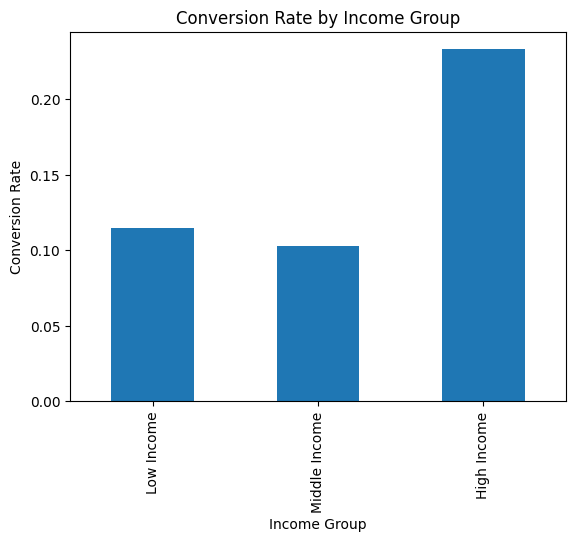

In [ ]:
#grafik
conversion_income.plot(kind='bar')

plt.title('Conversion Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Conversion Rate')

plt.show()

In [ ]:
##Interpretasi
#Berdasarkan grafik Conversion Rate by Income Group, terlihat bahwa kelompok pelanggan dengan pendapatan tinggi memiliki conversion rate paling tinggi dibandingkan kelompok lainnya.
#Hal ini menunjukkan bahwa pelanggan dengan pendapatan yang lebih besar cenderung lebih responsif terhadap campaign marketing yang diberikan oleh perusahaan.

#Sementara itu, kelompok pelanggan dengan pendapatan rendah dan menengah memiliki tingkat conversion rate yang lebih rendah.
#Hal ini mengindikasikan bahwa daya beli pelanggan dapat mempengaruhi kemungkinan mereka dalam merespon campaign marketing.

In [ ]:
###Membuat Convertion Rate Berdasarkan Tingkat Pengeluaran

In [ ]:
#Membuat Total Spending
df['Total_Spending'] = (
    df['MntCoke'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df[['Total_Spending']].head()

,Total_Spending
0,1617000
1,27000
2,776000
3,53000
4,422000


In [ ]:
#Membuat Kelompok Spending Low Spending, Medium Spending, High Spending
df['Spending_Group'] = pd.qcut(df['Total_Spending'],
                               q=3,
                               labels=['Low Spending','Medium Spending','High Spending'])

In [ ]:
#Menghitung Convertion Rate
conversion_spending = df.groupby('Spending_Group')['Response'].mean()
conversion_spending

/tmp/ipykernel_302/1573470033.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_spending = df.groupby('Spending_Group')['Response'].mean()


,Response
Spending_Group,
Low Spending,0.074866
Medium Spending,0.123490
High Spending,0.248996


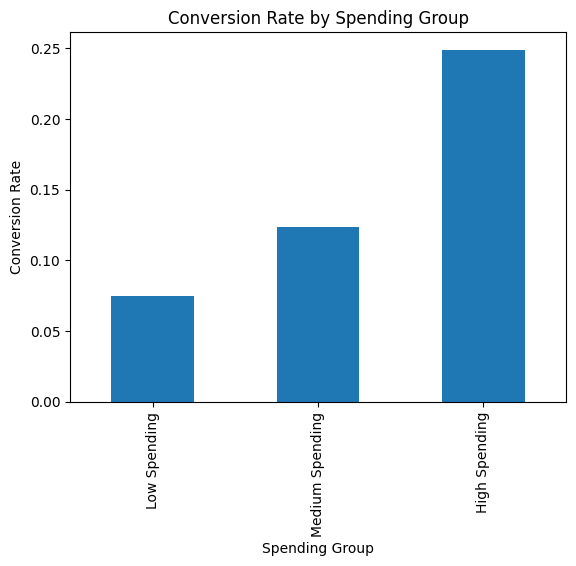

In [ ]:
#grafik
conversion_spending.plot(kind='bar')

plt.title('Conversion Rate by Spending Group')
plt.xlabel('Spending Group')
plt.ylabel('Conversion Rate')

plt.show()

In [ ]:
##Interpretasi
#Berdasarkan grafik Conversion Rate by Spending Group, terlihat bahwa kelompok pelanggan dengan tingkat pengeluaran yang lebih tinggi memiliki conversion rate yang lebih besar dibandingkan kelompok lainnya.
#Hal ini menunjukkan bahwa pelanggan yang sering melakukan pembelian atau memiliki pengeluaran yang lebih tinggi cenderung lebih responsif terhadap campaign marketing.

In [ ]:
###Kesimpulan
#Berdasarkan hasil analisis yang dilakukan, terlihat bahwa beberapa faktor pelanggan memiliki hubungan dengan tingkat conversion rate terhadap campaign marketing.
#Dari sisi demografi, kelompok umur Adult menunjukkan tingkat conversion rate yang lebih tinggi dibandingkan kelompok umur lainnya, yang menunjukkan bahwa pelanggan pada usia produktif lebih responsif terhadap campaign marketing.

#Selain itu, dari sisi ekonomi, pelanggan dengan High Income memiliki conversion rate tertinggi dibandingkan kelompok pendapatan lainnya.
#Hal ini menunjukkan bahwa pelanggan dengan daya beli yang lebih tinggi cenderung lebih tertarik untuk merespon penawaran yang diberikan oleh perusahaan.

#Dari sisi perilaku belanja, kelompok pelanggan dengan High Spending juga menunjukkan conversion rate tertinggi.
#Hal ini mengindikasikan bahwa pelanggan yang sering melakukan pembelian atau memiliki tingkat pengeluaran tinggi lebih berpotensi merespon campaign marketing.

#Secara keseluruhan, dapat disimpulkan bahwa umur, pendapatan, dan tingkat pengeluaran pelanggan memiliki pengaruh terhadap respon pelanggan terhadap campaign marketing.
#Oleh karena itu, perusahaan dapat mempertimbangkan untuk lebih memfokuskan strategi campaign marketing kepada pelanggan dengan usia produktif, pendapatan tinggi, serta tingkat pengeluaran yang besar untuk meningkatkan efektivitas pemasaran.